In [1]:
%run simplexalgo.ipynb

M/m m
number of variables 1
c_0 =  1
number of constraints 1
a_0,0 =  1
b_0 =  1


min z = 1.0x1

Subject to

1.0x1 <= 1.0
optimal solution is [1.]
optimal value is 1.0


In [2]:
%run neural.ipynb

M/m m
number of variables 1
c_0 =  1
number of constraints 1
a_0,0 =  1
b_0 =  1


min z = 1.0x1

Subject to

1.0x1 <= 1.0
optimal solution is [1.]
optimal value is 1.0
Dataset size: 177582
Epoch 1: 3.0650016440835834
Epoch 2: 2.8921422641526950
Epoch 3: 2.8270970630463830
Epoch 4: 2.7534476812737836
Epoch 5: 2.6562045440677871
Epoch 6: 2.5466051084755739
Epoch 7: 2.4494154467932399
Epoch 8: 2.3707242601248306
Epoch 9: 2.3091118443613592
Epoch 10: 2.2568807630732990
Epoch 11: 2.2068656944228007
Epoch 12: 2.1588985622560841
Epoch 13: 2.1184452784268619
Epoch 14: 2.0847779476779049
Epoch 15: 2.0533737121572329
Epoch 16: 2.0225297453647046
Epoch 17: 1.9963642679164348
Epoch 18: 1.9699144927613459
Epoch 19: 1.9489921734412883
Epoch 20: 1.9270163685045489
Epoch 21: 1.9052749483855209
Epoch 22: 1.8847638829727706
Epoch 23: 1.8675691151629064
Epoch 24: 1.8539797216464322
Epoch 25: 1.8392563616638216
Epoch 26: 1.8229710142356756
Epoch 27: 1.8126750290267495
Epoch 28: 1.7999085871129281
Epoch 29: 1.7887227114048385
Epoch 30: 1.7764861557937466
Epoch 31: 1.7671389047399120
Epo

<Figure size 640x480 with 0 Axes>

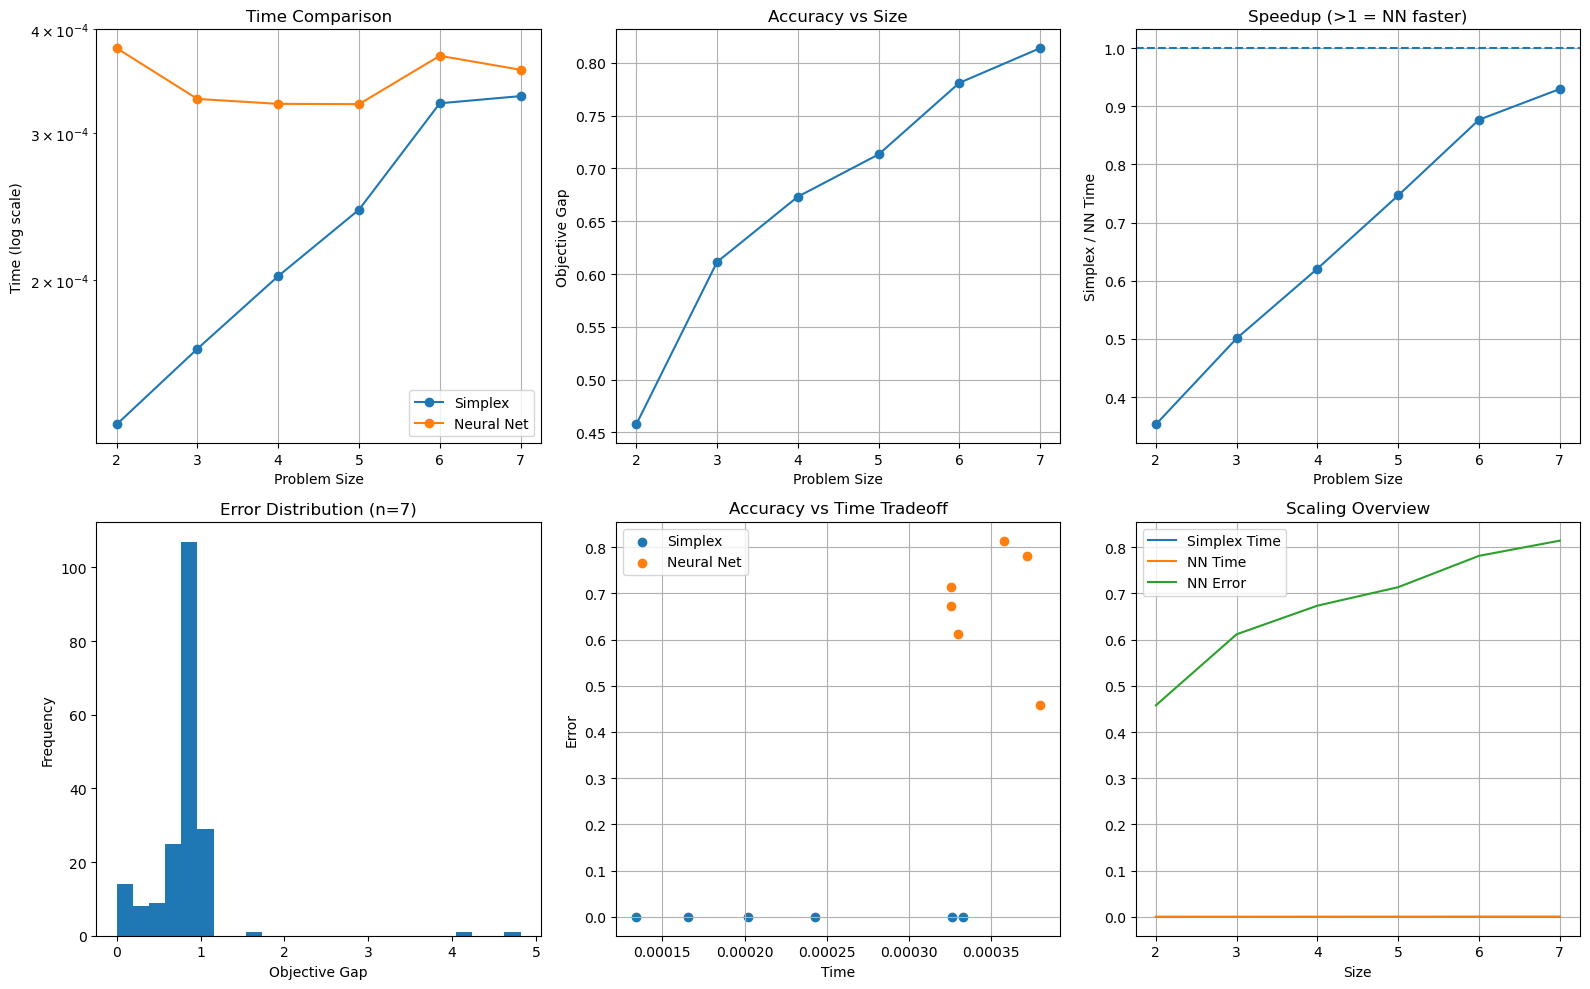

In [11]:
import time
import numpy as np
import torch
import matplotlib.pyplot as plt



# =========================
# SETUP
# =========================

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(DEVICE)
model.eval()

MAX_VARS = 7
MAX_CONS = 7

SIZES = [2, 3, 4, 5, 6, 7]
SAMPLES = 200


# =========================
# DATA GENERATION
# =========================

def generate_lpp(n):
    c = np.random.uniform(-3, 7, size=(n,))
    A = np.random.uniform(-5, 9, size=(n, n))
    b = np.random.uniform(0, 30, size=(n,))
    o = np.random.choice(['M', 'm'])
    return o, c, A, b


# =========================
# NN INPUT PREP
# =========================

def prepare_input(o, c, A, b):
    c_pad = np.zeros(MAX_VARS)
    c_pad[:len(c)] = c

    A_pad = np.zeros((MAX_CONS, MAX_VARS))
    A_pad[:A.shape[0], :A.shape[1]] = A

    b_pad = np.zeros(MAX_CONS)
    b_pad[:len(b)] = b

    X = np.concatenate([A_pad, b_pad.reshape(-1, 1)], axis=1)

    flag = np.array([1.0 if o == 'M' else -1.0])

    return (
        torch.tensor(X, dtype=torch.float32).unsqueeze(0),
        torch.tensor(flag, dtype=torch.float32).unsqueeze(0),
        torch.tensor(c_pad, dtype=torch.float32).unsqueeze(0),
    )


def objective(c, x):
    return np.dot(c, x)


# =========================
# BENCHMARK
# =========================

simplex_times = []
nn_times = []
nn_errors = []
all_errors = []

for n in SIZES:

    s_time = 0
    n_time = 0
    errors = []
    valid = 0

    for _ in range(SAMPLES):

        o, c, A, b = generate_lpp(n)

        # ---- SIMPLEX ----
        t0 = time.perf_counter()
        x_true = simplex(o, c, A, b)
        t1 = time.perf_counter()

        if x_true is None:
            continue

        s_time += (t1 - t0)

        # ---- NN ----
        X, flag, c_tensor = prepare_input(o, c, A, b)
        X, flag, c_tensor = X.to(DEVICE), flag.to(DEVICE), c_tensor.to(DEVICE)

        t0 = time.perf_counter()
        with torch.no_grad():
            pred = model(X, flag, c_tensor)
        t1 = time.perf_counter()

        n_time += (t1 - t0)

        pred = pred.cpu().numpy().flatten()[:n]

        # ---- ERROR ----
        true_obj = objective(c, x_true)
        pred_obj = objective(c, pred)

        err = abs(true_obj - pred_obj) / (abs(true_obj) + 1.0)

        errors.append(err)
        valid += 1

    # avoid division by zero
    if valid == 0:
        continue

    simplex_times.append(s_time / valid)
    nn_times.append(n_time / valid)
    nn_errors.append(np.mean(errors))
    all_errors.append(errors)


# =========================
# PLOTTING
# =========================

plt.savefig("time_plot.png", dpi=300)
plt.savefig("accuracy_plot.png", dpi=300)
plt.savefig("speedup_plot.png", dpi=300)
plt.savefig("tradeoff_plot.png", dpi=300)

plt.figure(figsize=(16, 10))

# -------------------------
# 1. TIME (LOG SCALE)
# -------------------------
plt.subplot(2, 3, 1)
plt.plot(SIZES, simplex_times, marker='o', label='Simplex')
plt.plot(SIZES, nn_times, marker='o', label='Neural Net')
plt.yscale('log')
plt.xlabel("Problem Size")
plt.ylabel("Time (log scale)")
plt.title("Time Comparison")
plt.legend()
plt.grid()

# -------------------------
# 2. ACCURACY
# -------------------------
plt.subplot(2, 3, 2)
plt.plot(SIZES, nn_errors, marker='o')
plt.xlabel("Problem Size")
plt.ylabel("Objective Gap")
plt.title("Accuracy vs Size")
plt.grid()

# -------------------------
# 3. SPEEDUP
# -------------------------
plt.subplot(2, 3, 3)
ratio = np.array(simplex_times) / np.array(nn_times)
plt.plot(SIZES, ratio, marker='o')
plt.axhline(1, linestyle='--')
plt.xlabel("Problem Size")
plt.ylabel("Simplex / NN Time")
plt.title("Speedup (>1 = NN faster)")
plt.grid()

# -------------------------
# 4. ERROR DISTRIBUTION (last size)
# -------------------------
plt.subplot(2, 3, 4)
plt.hist(all_errors[-1], bins=25)
plt.xlabel("Objective Gap")
plt.ylabel("Frequency")
plt.title(f"Error Distribution (n={SIZES[-1]})")

# -------------------------
# 5. ACCURACY vs TIME
# -------------------------
plt.subplot(2, 3, 5)
plt.scatter(simplex_times, [0]*len(simplex_times), label='Simplex')
plt.scatter(nn_times, nn_errors, label='Neural Net')
plt.xlabel("Time")
plt.ylabel("Error")
plt.title("Accuracy vs Time Tradeoff")
plt.legend()
plt.grid()

# -------------------------
# 6. COMBINED VIEW
# -------------------------
plt.subplot(2, 3, 6)
plt.plot(SIZES, simplex_times, label='Simplex Time')
plt.plot(SIZES, nn_times, label='NN Time')
plt.plot(SIZES, nn_errors, label='NN Error')
plt.xlabel("Size")
plt.title("Scaling Overview")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()